In [15]:
import pandas as pd
import numpy as np
import joblib
import pygad
import matplotlib.pyplot as plt


In [2]:
# LOAD MODELS

rf_cl = joblib.load("../models/tuned/rf_cl.pkl")
rf_cd = joblib.load("../models/tuned/rf_cd.pkl")
rf_cm = joblib.load("../models/tuned/rf_cm.pkl")

scaler= joblib.load("../models/tuned/scaler.pkl")

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# USER INPUTS

reynolds_raw = float(input("Enter Reynold's Number: "))
aoa_raw = float(input("Enter Angle of Attack (deg): "))

Enter Reynold's Number:  500000
Enter Angle of Attack (deg):  5


In [4]:
# LOAD DATASET FOR BOUNDS

df = pd.read_csv("../data/train_clean.csv")
features=[
    "max_thickness",
    "thickness_location",
    "max_camber",
    "camber_location"
]

full_features = [
    "reynolds",
    "aoa",
    "max_thickness",
    "thickness_location",
    "max_camber",
    "camber_location"
]

bounds = []
for col in features:
    bounds.append(
        (
            df[col].min(),
            df[col].max()
        )
    )
print("\nFeature Bounds:")
print(bounds)


Feature Bounds:
[(-2.1223132236313016, 4.019902572179529), (-2.49831099364531, 5.735113137157859), (-1.331106541587958, 3.432552864167586), (-1.8586642720435036, 3.1297812613031777)]


In [5]:
# SCALE USER INPUT ONCE

user_df = pd.DataFrame(
    [[reynolds_raw, aoa_raw, 0, 0, 0, 0]],
    columns=full_features
)

user_scaled = scaler.transform(user_df)

scaled_reynolds = user_scaled[0, 0]
scaled_aoa = user_scaled[0, 1]

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [6]:
# PREDICTION FUNCTION

def predict_performance(solution):

    X = pd.DataFrame(
        [[
            scaled_reynolds,
            scaled_aoa,
            solution[0],
            solution[1],
            solution[2],
            solution[3],
        ]],
        columns=full_features
    )

    X_scaled = scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=full_features)
    cl = rf_cl.predict(X_scaled)[0]
    cd = rf_cd.predict(X_scaled)[0]
    cm = rf_cm.predict(X_scaled)[0]

    return cl, cd, cm

In [7]:
# FITNESS FUNCTION

fitness_history = []

def fitness_function(
    ga_instance,
    solution,
    solution_idx
):

    cl, cd, cm = predict_performance(solution)
    
    if cd <= 0:
        return 0.0
    if cl <= 0:
        return 0.0
    if cm < -0.3 or cm > 0.1:
        return 0.0
        
    cl_cd = cl / cd
    cm_penalty = 5 * abs(cm + 0.05)
    fitness = cl_cd - cm_penalty
    
    return fitness

In [8]:
# CALLBACK

def on_generation(ga_instance):

    best_fitness = ga_instance.best_solution()[1]
    fitness_history.append(best_fitness)
    print(
        f"Generation {ga_instance.generations_completed}"
        f" | Best Fitness = {best_fitness:.4f}"
    )

In [9]:
# GENETIC ALGORITHM

gene_space = [{"low": b[0], "high": b[1]} for b in bounds]

ga = pygad.GA(
    num_generations=50,
    sol_per_pop=20,
    num_parents_mating=10,
    num_genes=4,
    gene_space=gene_space,
    fitness_func=fitness_function,
    mutation_num_genes=1,
    random_seed=42,
    on_generation=on_generation,
    stop_criteria=["saturate_10"]
)

In [10]:
# RUN OPTIMISATION

ga.run()
best_solution, best_fitness, best_idx = ga.best_solution()

cl,cd,cm = predict_performance(best_solution)



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X ha

Generation 1 | Best Fitness = 1.1572


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X ha

Generation 2 | Best Fitness = 1.1572


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X ha

...

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X ha

Generation 33 | Best Fitness = 2.6966


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X ha

Generation 34 | Best Fitness = 2.6966


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X ha

In [11]:
# INVERSE TRANSFORM (REAL GEOMETRY)

scaled_geom = np.array(best_solution).reshape(1, -1)

full_scaled = np.array([[
    scaled_reynolds,
    scaled_aoa,
    scaled_geom[0, 0],
    scaled_geom[0, 1],
    scaled_geom[0, 2],
    scaled_geom[0, 3]
]])

real_values = scaler.inverse_transform(full_scaled)

real_geom = real_values[0, 2:]
real_reynolds = real_values[0, 0]
real_aoa = real_values[0, 1]


In [12]:
# RESULTS

print("\n==============================")
print("OPTIMIZED AIRFOIL RESULT")
print("==============================")

print(f"Reynolds: {reynolds_raw}")
print(f"AoA: {aoa_raw}")

print("\nREAL AIRFOIL GEOMETRY")

print(f"Max Thickness      : {real_geom[0]:.6f}")
print(f"Thickness Location : {real_geom[1]:.6f}")
print(f"Max Camber         : {real_geom[2]:.6f}")
print(f"Camber Location    : {real_geom[3]:.6f}")

print("\nPredicted Performance\n")
print(f"CL : {cl:.6f}")
print(f"CD : {cd:.6f}")
print(f"CM : {cm:.6f}")
print(f"CL/CD : {cl/cd:.6f}")

print(f"\nBest Fitness: {best_fitness:.6f}")


OPTIMIZED AIRFOIL RESULT
Reynolds: 500000.0
AoA: 5.0

REAL AIRFOIL GEOMETRY
Max Thickness      : 0.108238
Thickness Location : 0.341879
Max Camber         : 0.077437
Camber Location    : 0.383891

Predicted Performance

CL : 0.218140
CD : 0.076629
CM : -0.080023
CL/CD : 2.846692

Best Fitness: 2.696579


In [17]:
#SAVE RESULTS

results = pd.DataFrame({
    "parameter": [
        "reynolds",
        "aoa",
        "max_thickness",
        "thickness_location",
        "max_camber",
        "camber_location",
        "cl",
        "cd",
        "cm",
        "cl_cd"
    ],
    "value": [
        reynolds_raw,
        aoa_raw,
        real_geom[0],
        real_geom[1],
        real_geom[2],
        real_geom[3],
        cl,
        cd,
        cm,
        cl / cd
    ]
})

results.to_csv("../optimization_results.csv", index=False)

print("\nResults saved to optimization_results.csv")


Results saved to optimization_results.csv


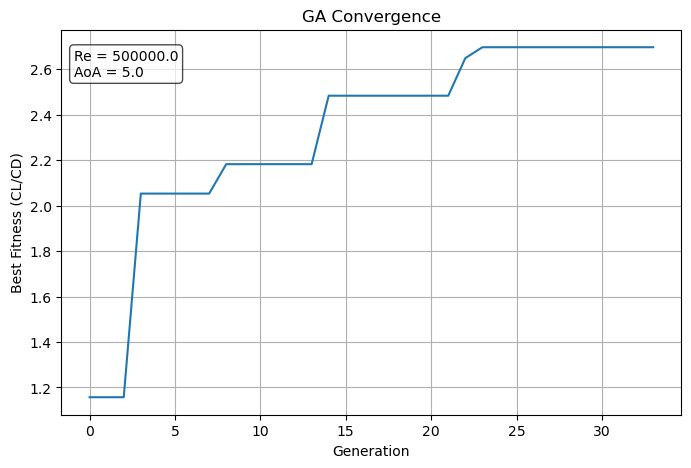

/BEST Solution Vector (Scaled):
[-0.31364098  0.26532068  2.2846817   0.05635618]


In [18]:
# CONVERGENCE PLOT

plot.figure(figsize=(8,5))

plot.plot(fitness_history)

plot.xlabel("Generation")
plot.ylabel("Best Fitness (CL/CD)")
plot.title("GA Convergence")

plot.grid(True)

plt.text(
    0.02, 0.95,
    f"Re = {reynolds_raw}\nAoA = {aoa_raw}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plot.savefig(
    "../convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plot.show()

print("/BEST Solution Vector (Scaled):")
print(best_solution)